In [46]:
# ── Core Libraries ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Clustering ────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Hierarchical Dendrogram ───────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Plot styling ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


In [47]:
# ── Load Dataset ──────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv'

df = pd.read_csv(URL)

# Rename columns for easier use
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded: 200 rows × 5 columns


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [48]:
# ── First Look ────────────────────────────────────────────────────────────
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Basic Statistics ===')
print(df.describe().round(2))

print('\n=== Gender Distribution ===')
print(df['Gender'].value_counts())

=== Shape ===
(200, 5)

=== Data Types ===
CustomerID         int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object

=== Missing Values ===
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

=== Basic Statistics ===
       CustomerID     Age  Annual_Income  Spending_Score
count      200.00  200.00         200.00          200.00
mean       100.50   38.85          60.56           50.20
std         57.88   13.97          26.26           25.82
min          1.00   18.00          15.00            1.00
25%         50.75   28.75          41.50           34.75
50%        100.50   36.00          61.50           50.00
75%        150.25   49.00          78.00           73.00
max        200.00   70.00         137.00           99.00

=== Gender Distribution ===
Gender
Female    112
Male       88
Name: count, dtype: int64


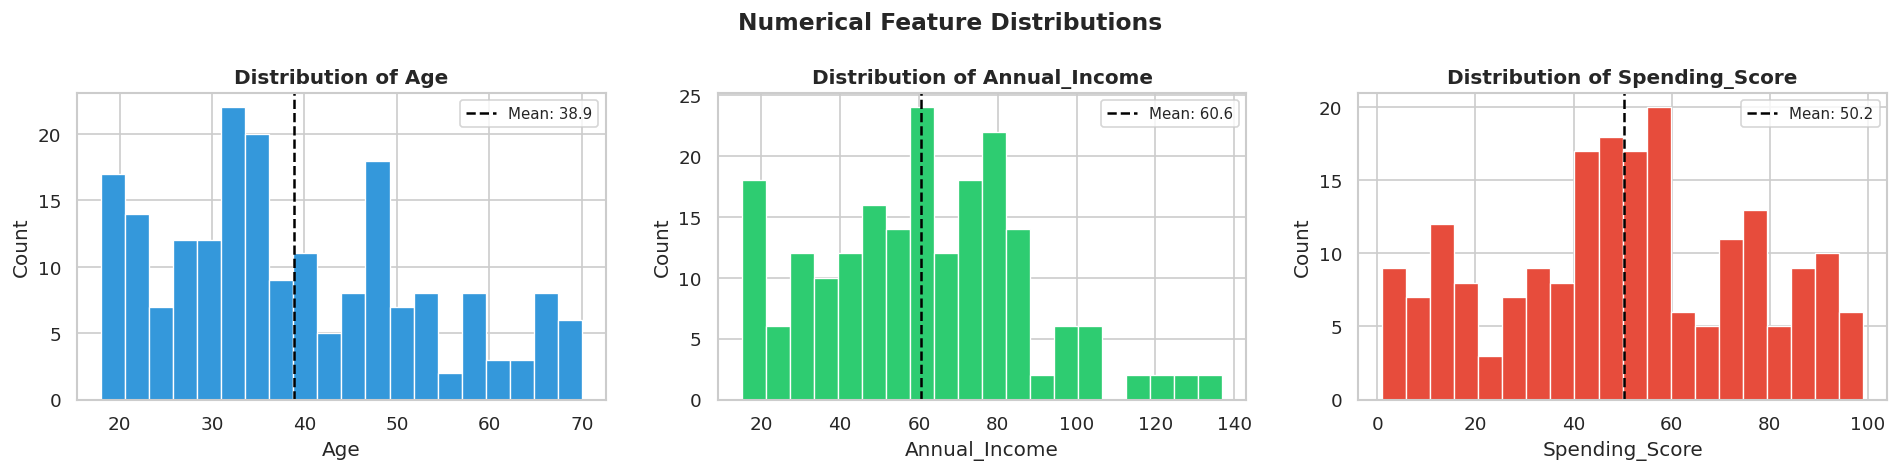

In [49]:
# ── 2.1 Distribution of All Numerical Features ────────────────────────────
num_cols = ['Age', 'Annual_Income', 'Spending_Score']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='white', linewidth=0.8)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

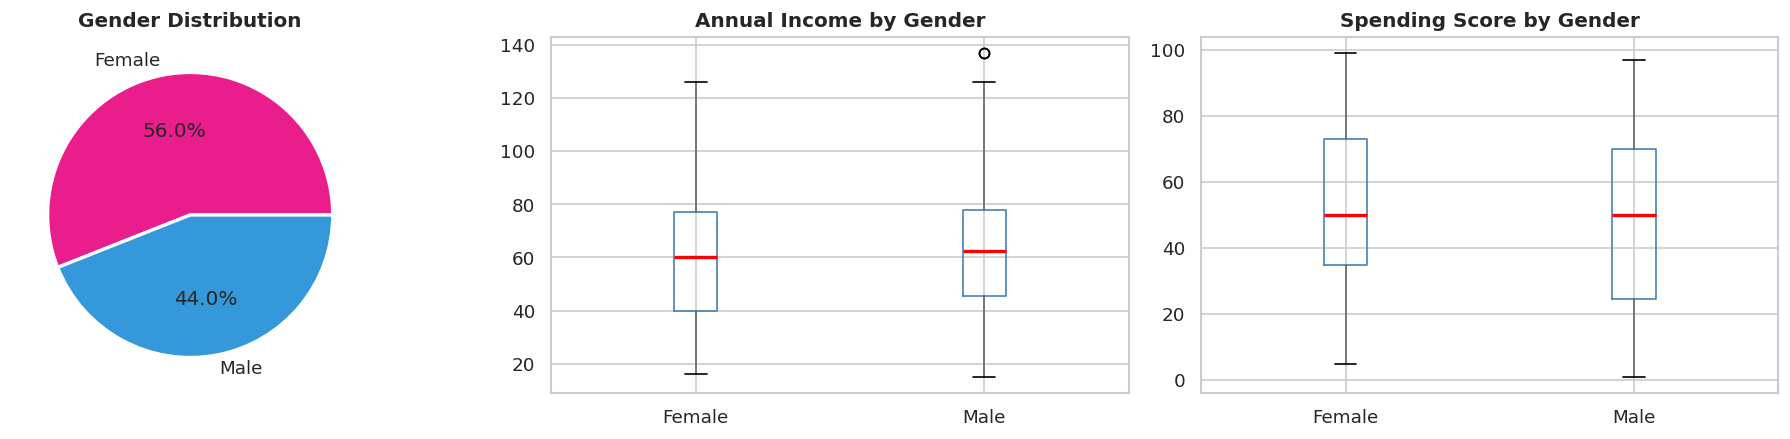

💡 Insight: Females slightly outnumber males and tend to have higher spending scores


In [50]:
# ── 2.2 Gender Distribution & Spending by Gender ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gender count
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#e91e8c', '#3498db'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Gender Distribution', fontweight='bold')

# Annual income by gender
df.boxplot(column='Annual_Income', by='Gender', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Annual Income by Gender', fontweight='bold')
axes[1].set_xlabel('')

# Spending score by gender
df.boxplot(column='Spending_Score', by='Gender', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Spending Score by Gender', fontweight='bold')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('💡 Insight: Females slightly outnumber males and tend to have higher spending scores')

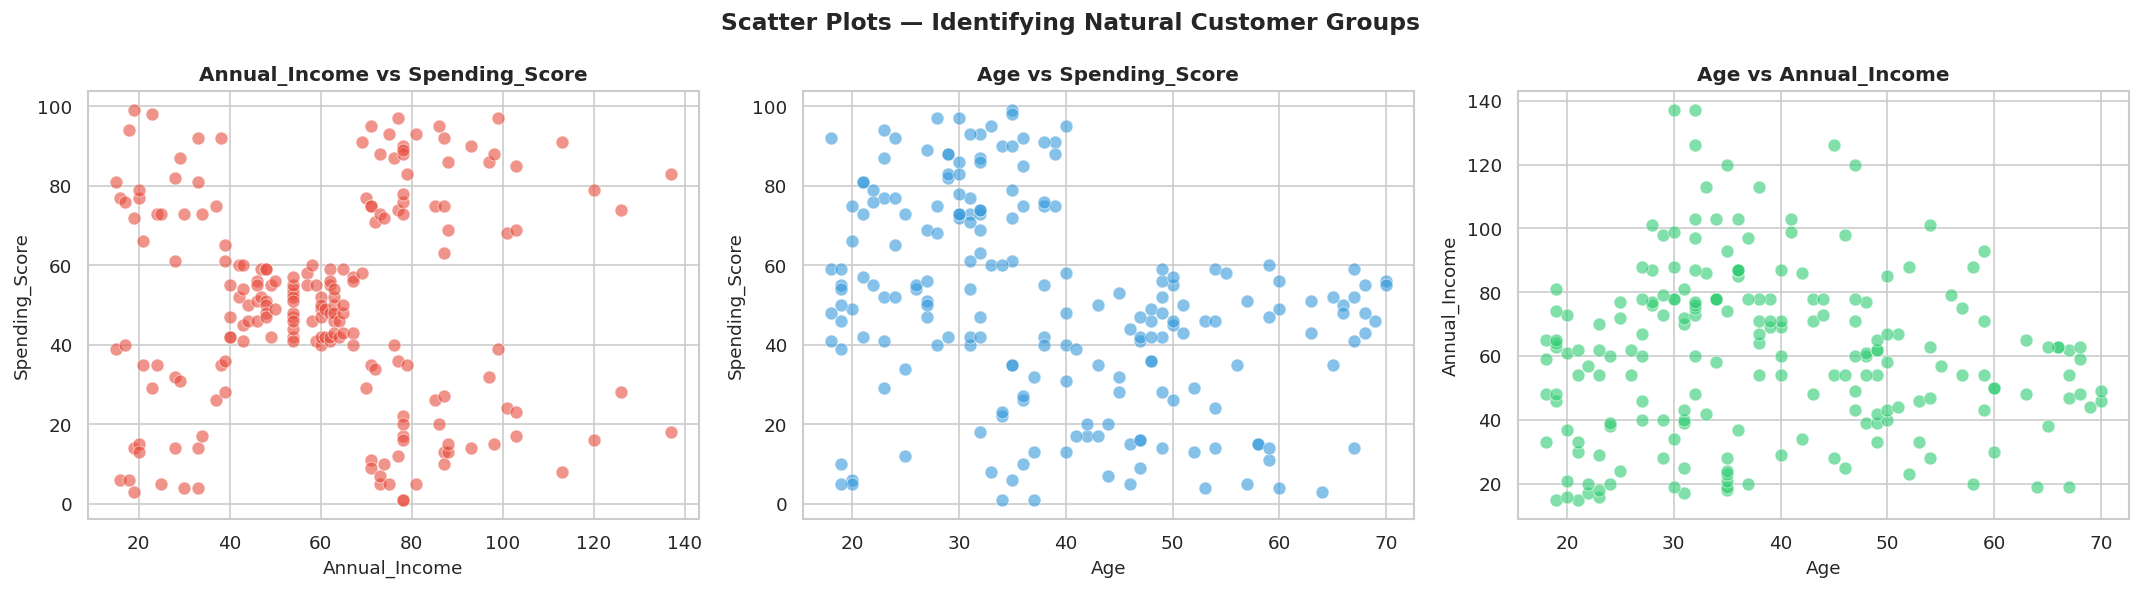

💡 Insight: Annual Income vs Spending Score shows ~5 clear natural clusters!
   This is the primary feature pair we will cluster on.


In [51]:
# ── 2.3 Key Scatter Plots — The Clustering Story ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [
    ('Annual_Income', 'Spending_Score', '#e74c3c'),
    ('Age',           'Spending_Score', '#3498db'),
    ('Age',           'Annual_Income',  '#2ecc71'),
]

for ax, (x, y, color) in zip(axes, scatter_pairs):
    ax.scatter(df[x], df[y], c=color, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)
    ax.set_xlabel(x, fontsize=11)
    ax.set_ylabel(y, fontsize=11)
    ax.set_title(f'{x} vs {y}', fontsize=12, fontweight='bold')

plt.suptitle('Scatter Plots — Identifying Natural Customer Groups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Insight: Annual Income vs Spending Score shows ~5 clear natural clusters!')
print('   This is the primary feature pair we will cluster on.')

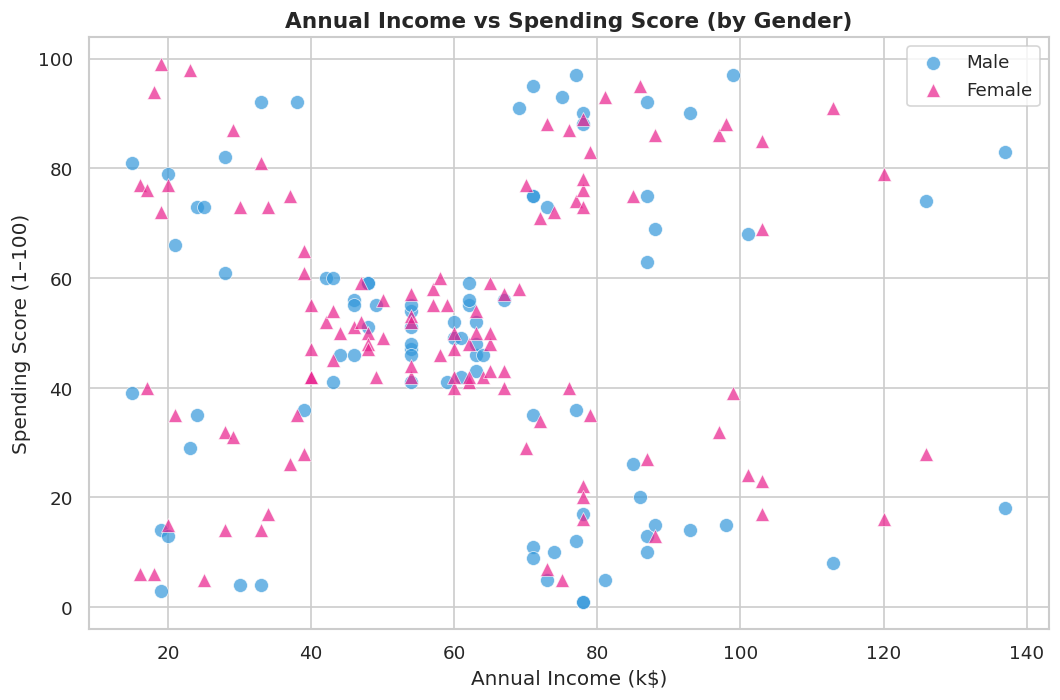

In [52]:
# ── 2.4 Scatter by Gender (colored) ──────────────────────────────────────
plt.figure(figsize=(9, 6))

for gender, color, marker in [('Male', '#3498db', 'o'), ('Female', '#e91e8c', '^')]:
    subset = df[df['Gender'] == gender]
    plt.scatter(subset['Annual_Income'], subset['Spending_Score'],
                c=color, label=gender, alpha=0.7,
                edgecolors='white', linewidth=0.5, s=70, marker=marker)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title('Annual Income vs Spending Score (by Gender)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

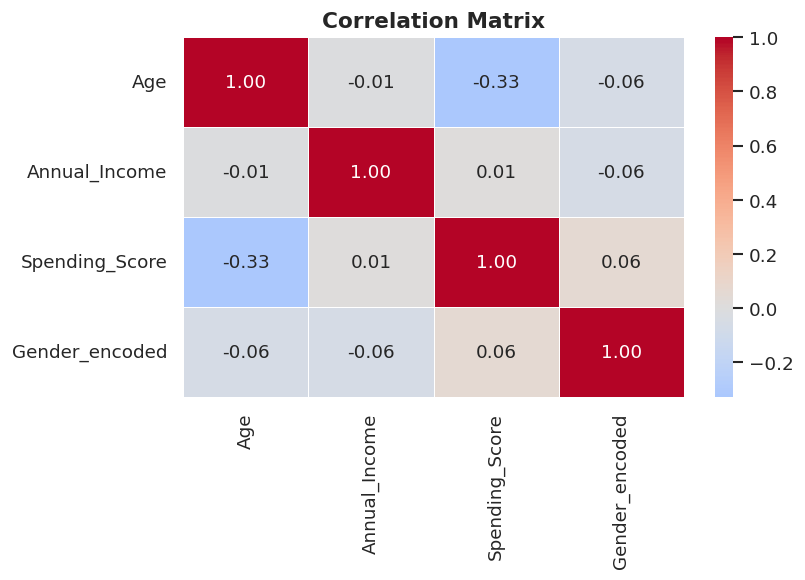

💡 Key finding: Low correlations between features → good for clustering!
   Each feature adds independent information.


In [53]:
# ── 2.5 Correlation Heatmap ───────────────────────────────────────────────
plt.figure(figsize=(7, 5))

# Encode gender for correlation
df_corr = df.copy()
df_corr['Gender_encoded'] = (df_corr['Gender'] == 'Female').astype(int)

corr = df_corr[['Age', 'Annual_Income', 'Spending_Score', 'Gender_encoded']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 11})

plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key finding: Low correlations between features → good for clustering!')
print('   Each feature adds independent information.')

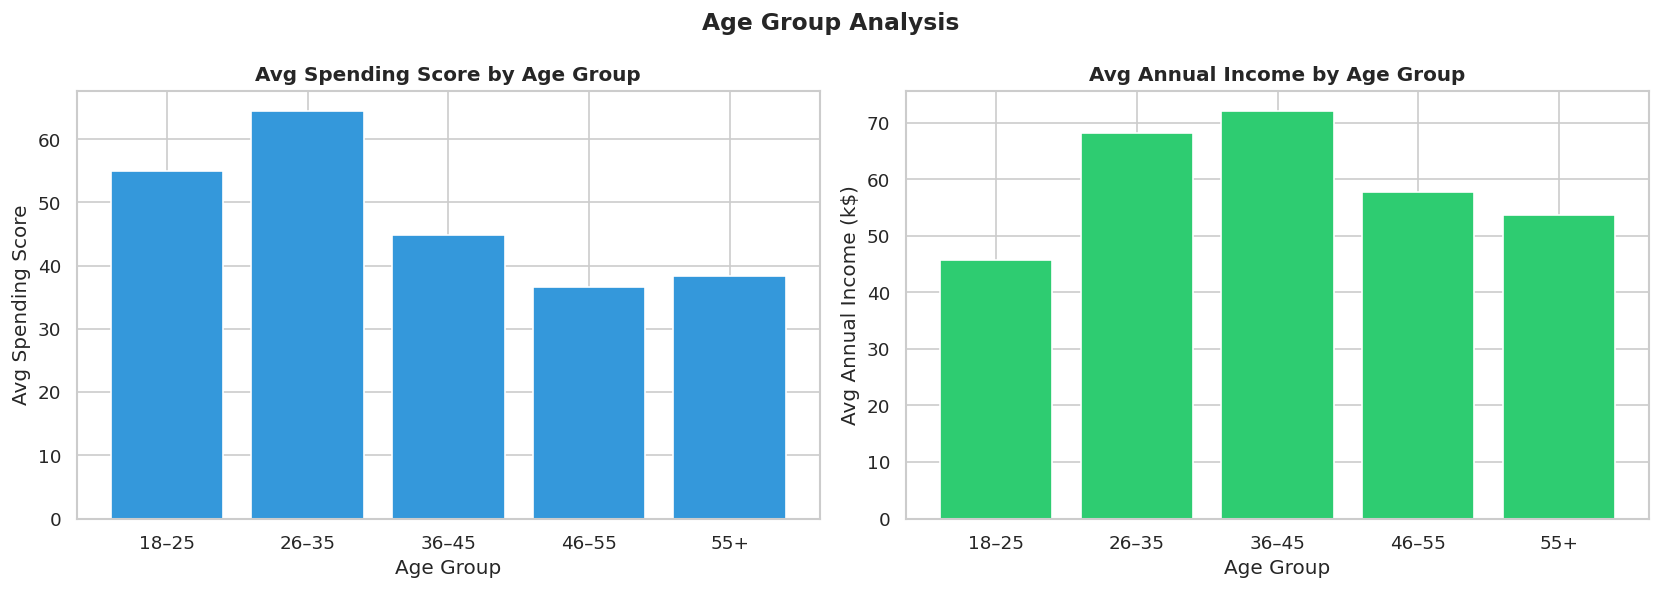

💡 Insight: Younger customers (18–25) have highest spending scores despite lower incomes


In [54]:
# ── 2.6 Age Group Analysis ────────────────────────────────────────────────
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['18–25', '26–35', '36–45', '46–55', '55+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spending score by age group
age_spending = df.groupby('Age_Group', observed=True)['Spending_Score'].mean().reset_index()
axes[0].bar(age_spending['Age_Group'], age_spending['Spending_Score'],
            color='#3498db', edgecolor='white')
axes[0].set_title('Avg Spending Score by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Avg Spending Score')

# Annual income by age group
age_income = df.groupby('Age_Group', observed=True)['Annual_Income'].mean().reset_index()
axes[1].bar(age_income['Age_Group'], age_income['Annual_Income'],
            color='#2ecc71', edgecolor='white')
axes[1].set_title('Avg Annual Income by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Annual Income (k$)')

plt.suptitle('Age Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Drop temp column
df.drop(columns=['Age_Group'], inplace=True)

print('💡 Insight: Younger customers (18–25) have highest spending scores despite lower incomes')


In [55]:
# ── 3.1 Encode Gender ─────────────────────────────────────────────────────
df['Gender_encoded'] = (df['Gender'] == 'Female').astype(int)

print('Gender encoding: Female → 1, Male → 0')
print(df[['Gender', 'Gender_encoded']].head(6))

Gender encoding: Female → 1, Male → 0
   Gender  Gender_encoded
0    Male               0
1    Male               0
2  Female               1
3  Female               1
4  Female               1
5  Female               1


In [56]:
# ── 3.2 Define Feature Sets ───────────────────────────────────────────────
# We will cluster on two feature sets:
# Set A: Income + Spending only (2D — easiest to visualize, clearest clusters)
# Set B: Age + Income + Spending (3D — richer segmentation)

features_2d = ['Annual_Income', 'Spending_Score']
features_3d = ['Age', 'Annual_Income', 'Spending_Score']

X_2d = df[features_2d].copy()
X_3d = df[features_3d].copy()

print(f'Feature Set A (2D): {features_2d}')
print(f'Feature Set B (3D): {features_3d}')

Feature Set A (2D): ['Annual_Income', 'Spending_Score']
Feature Set B (3D): ['Age', 'Annual_Income', 'Spending_Score']


In [57]:
# ── 3.3 Scale Features ────────────────────────────────────────────────────
scaler_2d = StandardScaler()
scaler_3d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print('Before scaling (first 3 rows):')
print(X_2d.head(3).to_string())
print()
print('After scaling (first 3 rows):')
print(pd.DataFrame(X_2d_scaled, columns=features_2d).head(3).round(3).to_string())
print()
print('✅ Scaling complete — all features now have mean=0 and std=1')

Before scaling (first 3 rows):
   Annual_Income  Spending_Score
0             15              39
1             15              81
2             16               6

After scaling (first 3 rows):
   Annual_Income  Spending_Score
0         -1.739          -0.435
1         -1.739           1.196
2         -1.701          -1.716

✅ Scaling complete — all features now have mean=0 and std=1


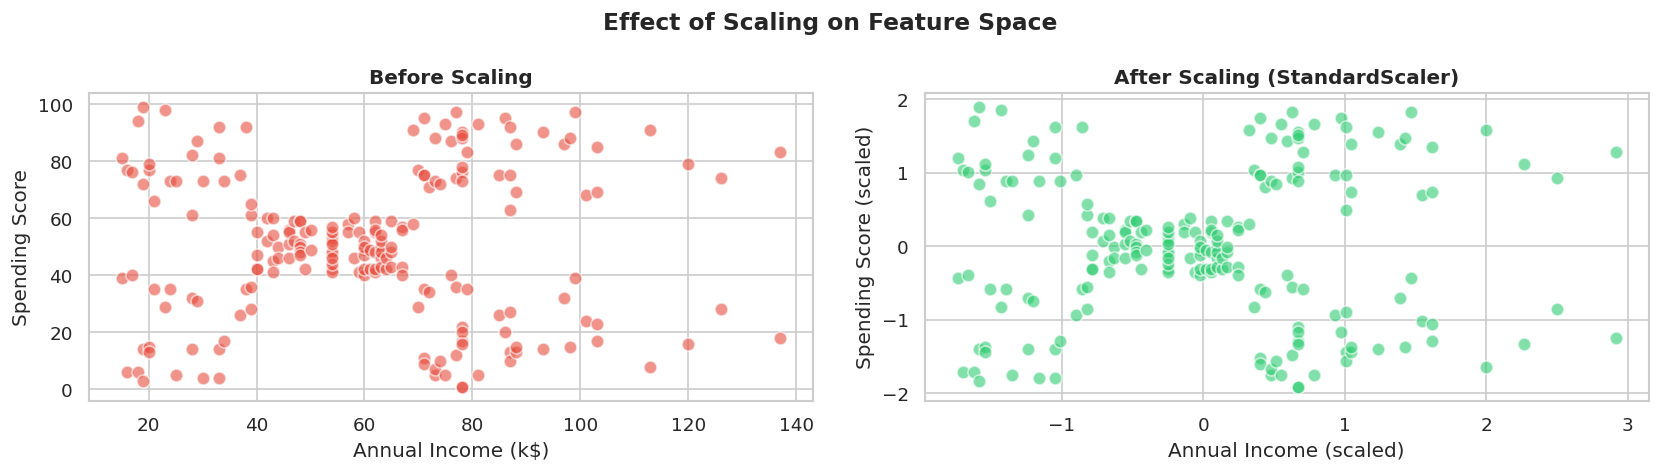

💡 Shape of clusters is preserved — only the axis scale changes.


In [58]:
# ── 3.4 Before vs After Scaling (visual check) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
axes[0].scatter(X_2d['Annual_Income'], X_2d['Spending_Score'],
                alpha=0.6, color='#e74c3c', edgecolors='white', s=60)
axes[0].set_title('Before Scaling', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')

# After
axes[1].scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1],
                alpha=0.6, color='#2ecc71', edgecolors='white', s=60)
axes[1].set_title('After Scaling (StandardScaler)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual Income (scaled)')
axes[1].set_ylabel('Spending Score (scaled)')

plt.suptitle('Effect of Scaling on Feature Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Shape of clusters is preserved — only the axis scale changes.')

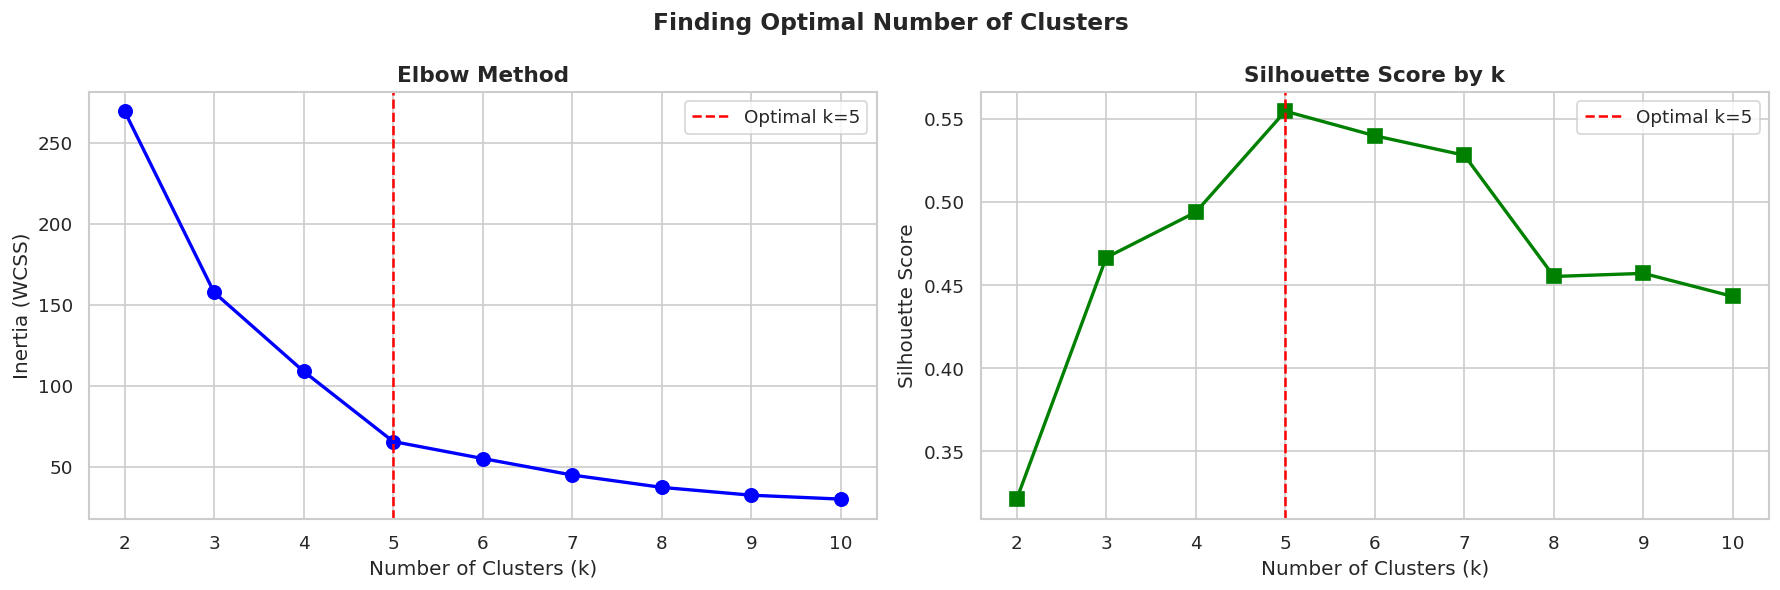

📊 Silhouette Scores per k:
   k=2: 0.3213
   k=3: 0.4666
   k=4: 0.4939
   k=5: 0.5547 ← Best
   k=6: 0.5399
   k=7: 0.5281
   k=8: 0.4552
   k=9: 0.4571
   k=10: 0.4432


In [59]:
# ── 4.1 Elbow Method ──────────────────────────────────────────────────────
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_2d_scaled, km.labels_))

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal k=5')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(K_range))

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal k=5')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xticks(list(K_range))

plt.suptitle('Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 Silhouette Scores per k:')
for k, s in zip(K_range, silhouette_scores):
    marker = ' ← Best' if s == max(silhouette_scores) else ''
    print(f'   k={k}: {s:.4f}{marker}')

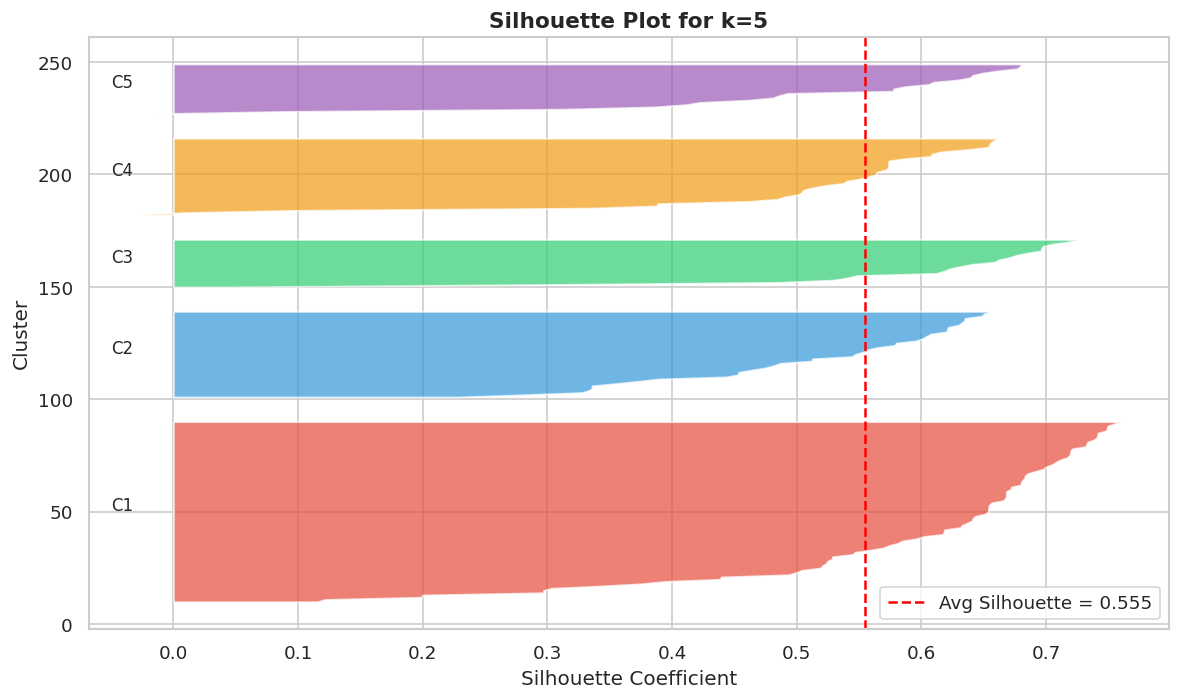

In [60]:
# ── 4.2 Silhouette Plot for k=5 ───────────────────────────────────────────
# A silhouette plot shows how well each sample fits its cluster
k_optimal = 5
km_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
labels_km = km_final.fit_predict(X_2d_scaled)

sample_silhouette_values = silhouette_samples(X_2d_scaled, labels_km)
avg_score = silhouette_score(X_2d_scaled, labels_km)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

for i in range(k_optimal):
    ith_vals = sample_silhouette_values[labels_km == i]
    ith_vals.sort()
    size = ith_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=colors_list[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'C{i+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg Silhouette = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot for k={k_optimal}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

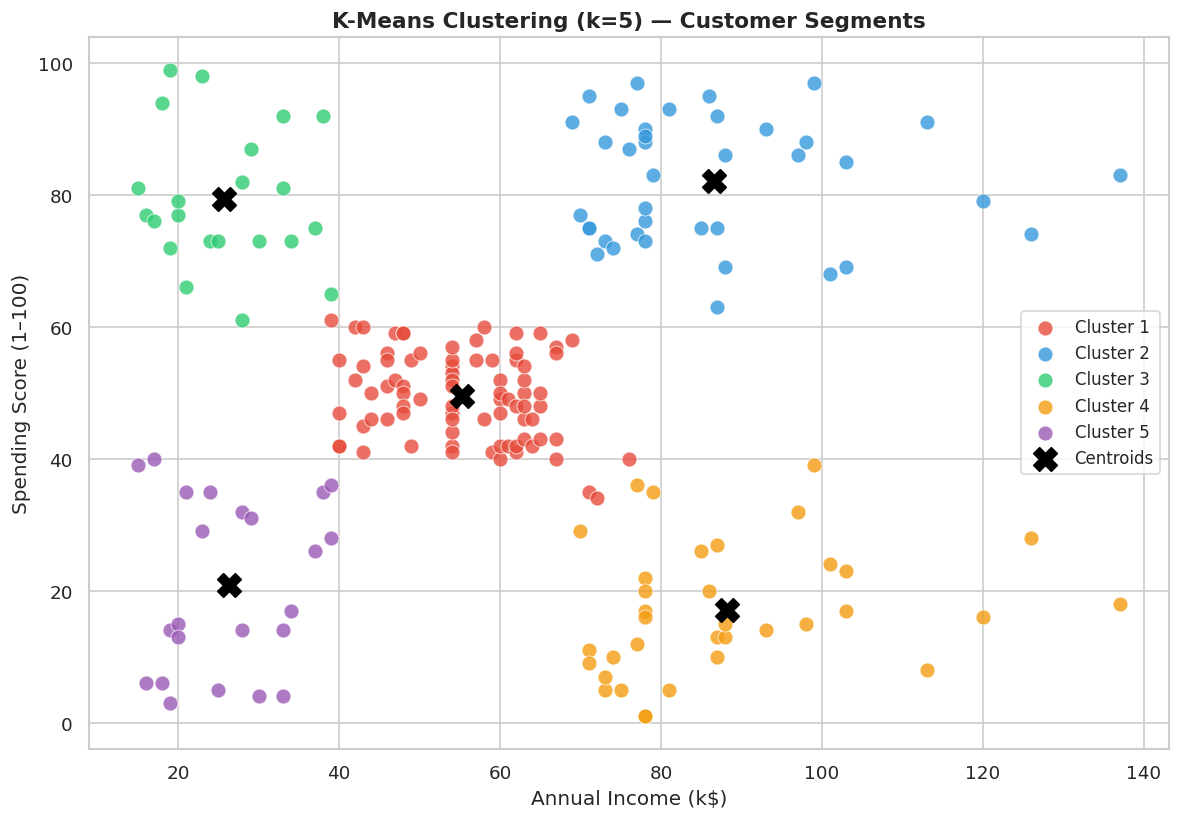

✅ K-Means complete — 5 clear customer segments identified!


In [61]:
# ── 4.3 Final K-Means Cluster Plot ────────────────────────────────────────
df['KMeans_Cluster'] = labels_km + 1   # label clusters 1–5
centroids = scaler_2d.inverse_transform(km_final.cluster_centers_)

plt.figure(figsize=(10, 7))
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

for cluster_id, color in zip(range(1, k_optimal + 1), colors_list):
    subset = df[df['KMeans_Cluster'] == cluster_id]
    plt.scatter(subset['Annual_Income'], subset['Spending_Score'],
                c=color, label=f'Cluster {cluster_id}',
                alpha=0.8, edgecolors='white', linewidth=0.5, s=80)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title(f'K-Means Clustering (k={k_optimal}) — Customer Segments',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('✅ K-Means complete — 5 clear customer segments identified!')

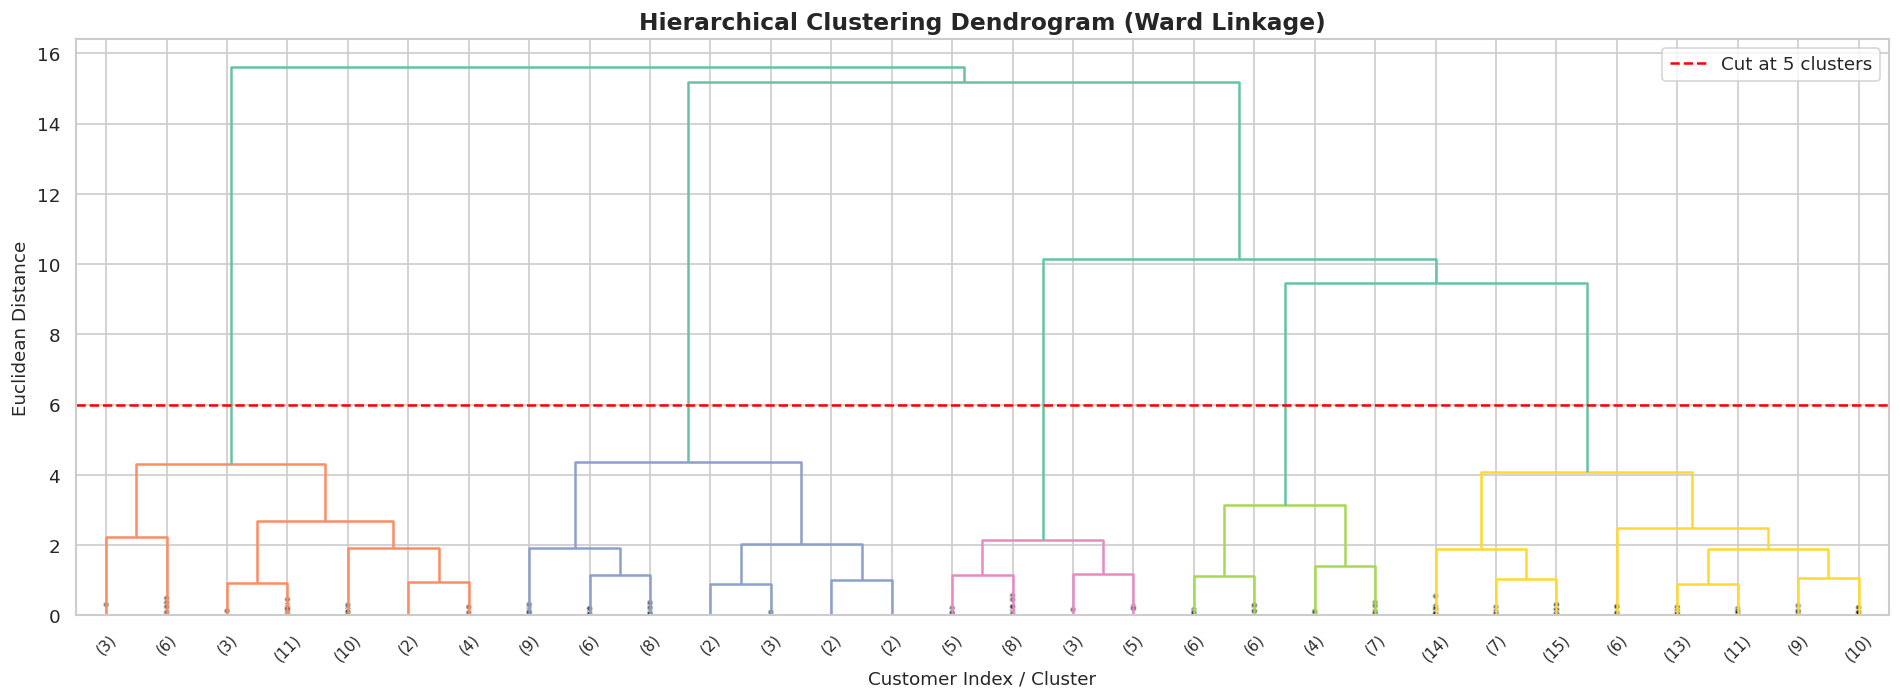

💡 How to read: Cut the tree horizontally at the red line → 5 clusters
   Tall vertical lines = large gaps between clusters = well-separated groups


In [62]:
# ── 5.1 Dendrogram ────────────────────────────────────────────────────────
# Use Ward linkage — minimizes variance within clusters
linked = linkage(X_2d_scaled, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(
    linked,
    truncate_mode='lastp',   # show only last p merged clusters
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=6
)
plt.axhline(y=6, color='red', linestyle='--', linewidth=1.5, label='Cut at 5 clusters')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index / Cluster', fontsize=11)
plt.ylabel('Euclidean Distance', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('💡 How to read: Cut the tree horizontally at the red line → 5 clusters')
print('   Tall vertical lines = large gaps between clusters = well-separated groups')

In [63]:
# ── 5.2 Fit Agglomerative Clustering (k=5) ────────────────────────────────
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)
labels_hc = hc.fit_predict(X_2d_scaled)
df['HC_Cluster'] = labels_hc + 1

hc_silhouette = silhouette_score(X_2d_scaled, labels_hc)
print(f'Hierarchical Clustering Silhouette Score (k=5): {hc_silhouette:.4f}')
print(f'K-Means Silhouette Score (k=5)               : {silhouette_score(X_2d_scaled, labels_km):.4f}')

Hierarchical Clustering Silhouette Score (k=5): 0.5538
K-Means Silhouette Score (k=5)               : 0.5547


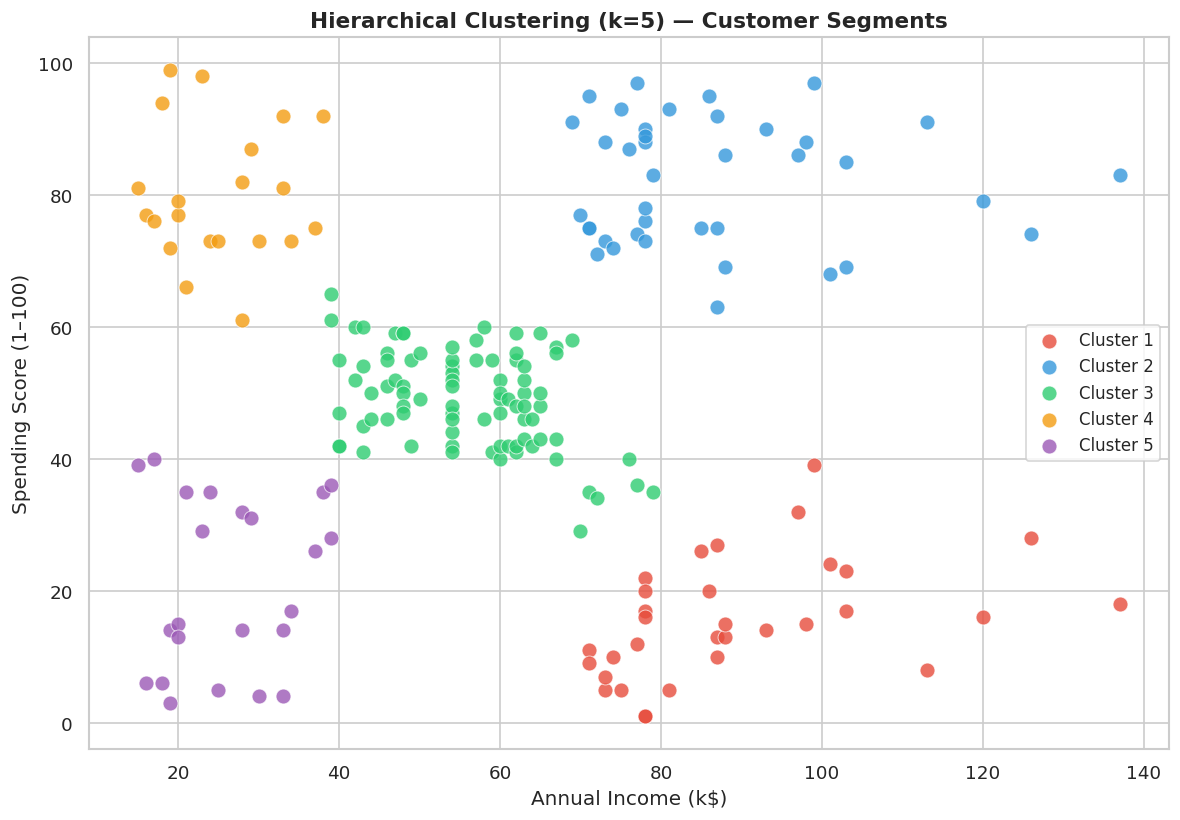

In [64]:
# ── 5.3 Hierarchical Cluster Plot ─────────────────────────────────────────
plt.figure(figsize=(10, 7))
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

for cluster_id, color in zip(range(1, 6), colors_list):
    subset = df[df['HC_Cluster'] == cluster_id]
    plt.scatter(subset['Annual_Income'], subset['Spending_Score'],
                c=color, label=f'Cluster {cluster_id}',
                alpha=0.8, edgecolors='white', linewidth=0.5, s=80)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title('Hierarchical Clustering (k=5) — Customer Segments', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

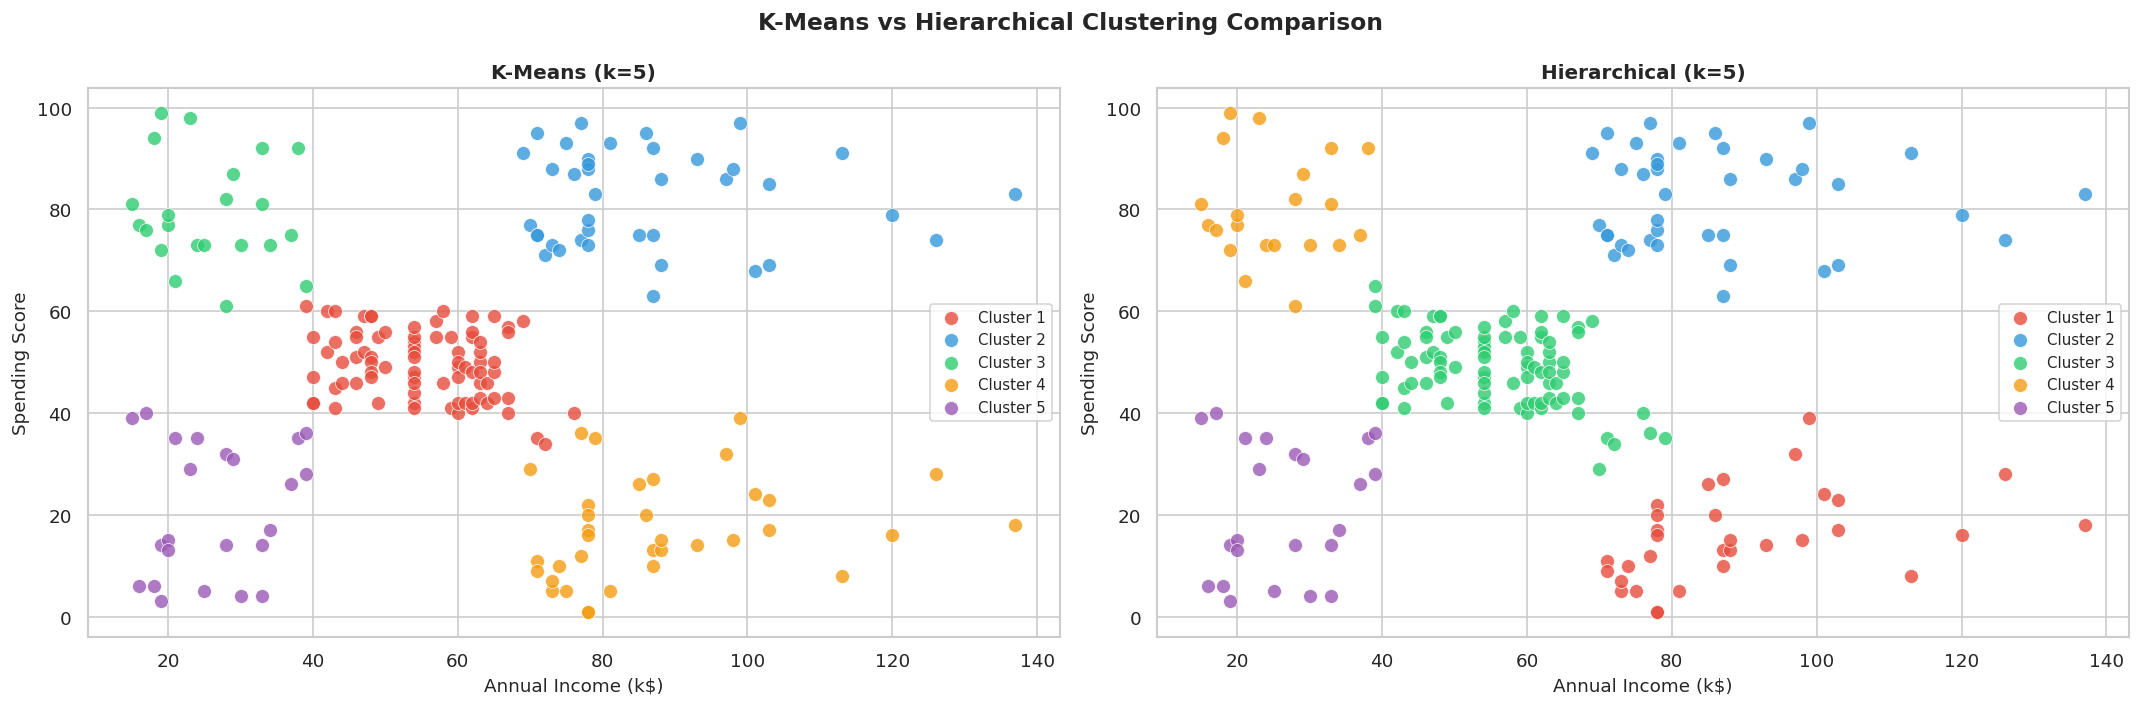

💡 Both methods produce very similar cluster assignments on this dataset.
   This confirms the 5-cluster structure is robust and not algorithm-dependent.


In [65]:
# ── 5.4 K-Means vs Hierarchical — Side by Side ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

for ax, cluster_col, title in zip(
    axes,
    ['KMeans_Cluster', 'HC_Cluster'],
    ['K-Means (k=5)', 'Hierarchical (k=5)']
):
    for cluster_id, color in zip(range(1, 6), colors_list):
        subset = df[df[cluster_col] == cluster_id]
        ax.scatter(subset['Annual_Income'], subset['Spending_Score'],
                   c=color, label=f'Cluster {cluster_id}',
                   alpha=0.8, edgecolors='white', linewidth=0.5, s=70)
    ax.set_xlabel('Annual Income (k$)', fontsize=11)
    ax.set_ylabel('Spending Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('K-Means vs Hierarchical Clustering Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Both methods produce very similar cluster assignments on this dataset.')
print('   This confirms the 5-cluster structure is robust and not algorithm-dependent.')

Explained variance ratio: [0.443 0.333]
Total variance captured : 77.6%


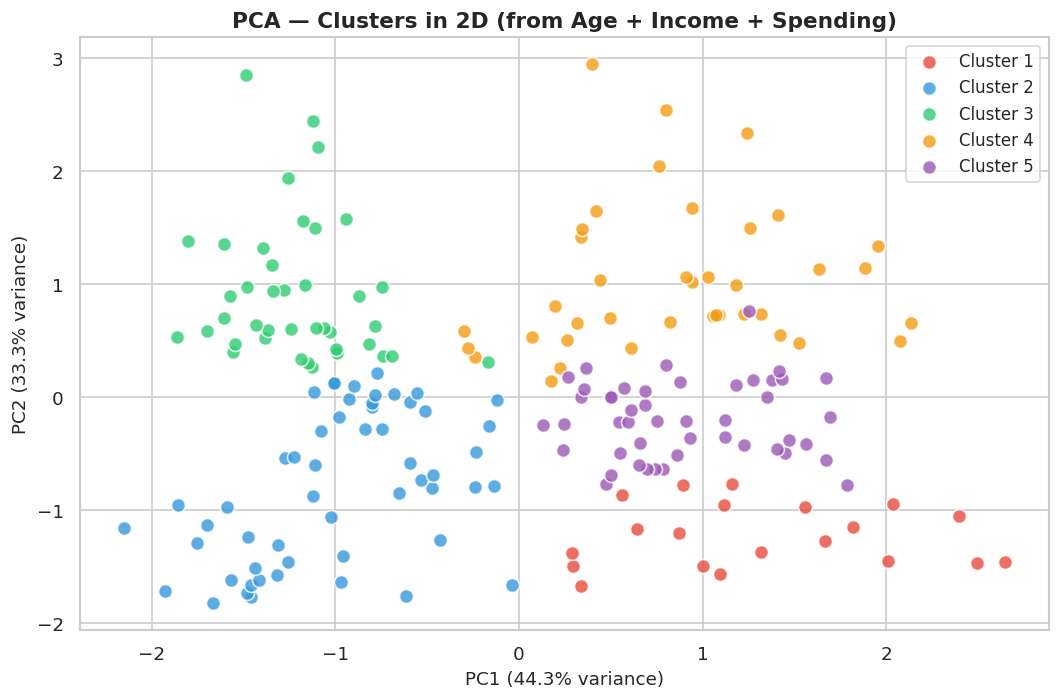

In [66]:
# ── 6.1 PCA on 3D Features ────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_3d_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variance captured : {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Re-run K-Means on 3D features
km_3d = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels_3d = km_3d.fit_predict(X_3d_scaled)
df['KMeans_3D_Cluster'] = labels_3d + 1

# Plot PCA
plt.figure(figsize=(9, 6))
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for cluster_id, color in zip(range(1, 6), colors_list):
    mask = labels_3d == (cluster_id - 1)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f'Cluster {cluster_id}',
                alpha=0.8, edgecolors='white', s=70)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.title('PCA — Clusters in 2D (from Age + Income + Spending)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

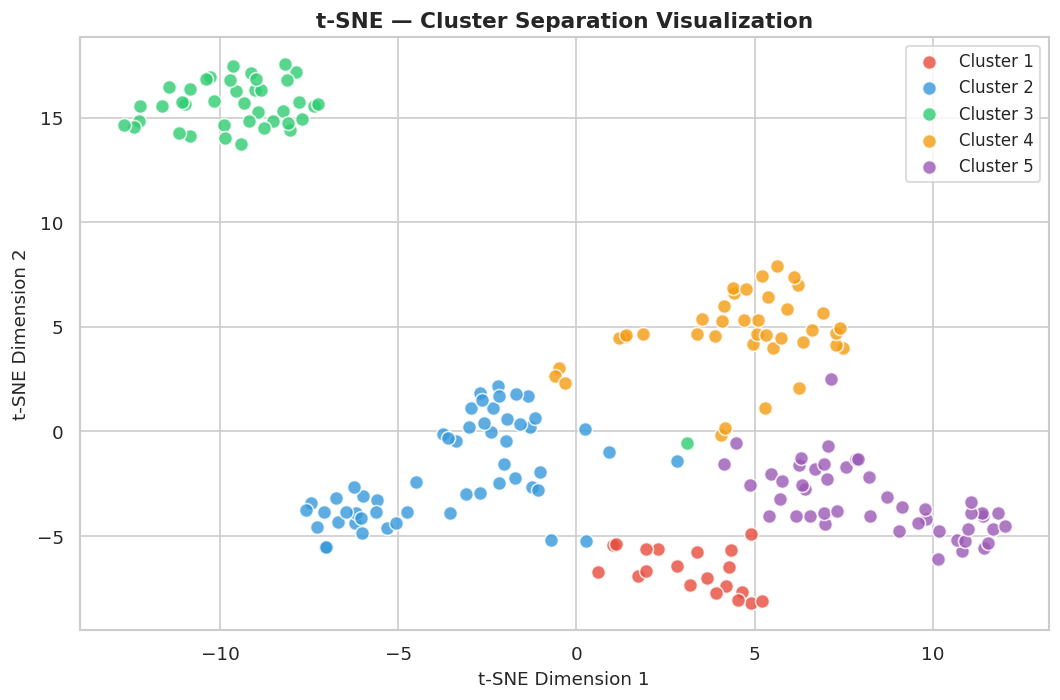

💡 t-SNE confirms clusters are well-separated with minimal overlap.


In [67]:
# ── 6.2 t-SNE Visualization ───────────────────────────────────────────────
# t-SNE preserves local structure — great for visualizing cluster separation
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_3d_scaled)

plt.figure(figsize=(9, 6))
for cluster_id, color in zip(range(1, 6), colors_list):
    mask = labels_3d == (cluster_id - 1)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=f'Cluster {cluster_id}',
                alpha=0.8, edgecolors='white', s=70)

plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.title('t-SNE — Cluster Separation Visualization', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('💡 t-SNE confirms clusters are well-separated with minimal overlap.')

In [68]:
# ── 7.1 Cluster Profiles — K-Means ───────────────────────────────────────
profile = df.groupby('KMeans_Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
profile['Count'] = df['KMeans_Cluster'].value_counts().sort_index()
profile['Gender_Female%'] = df.groupby('KMeans_Cluster')['Gender'].apply(
    lambda x: round((x == 'Female').mean() * 100, 1)
)

# Assign business labels
# Sort by income then spending to assign meaningful names
print('=' * 65)
print('           CUSTOMER SEGMENT PROFILES (K-Means)')
print('=' * 65)
print(profile.to_string())
print('=' * 65)

           CUSTOMER SEGMENT PROFILES (K-Means)
                 Age  Annual_Income  Spending_Score  Count  Gender_Female%
KMeans_Cluster                                                            
1               42.7           55.3            49.5     81            59.3
2               32.7           86.5            82.1     39            53.8
3               25.3           25.7            79.4     22            59.1
4               41.1           88.2            17.1     35            45.7
5               45.2           26.3            20.9     23            60.9


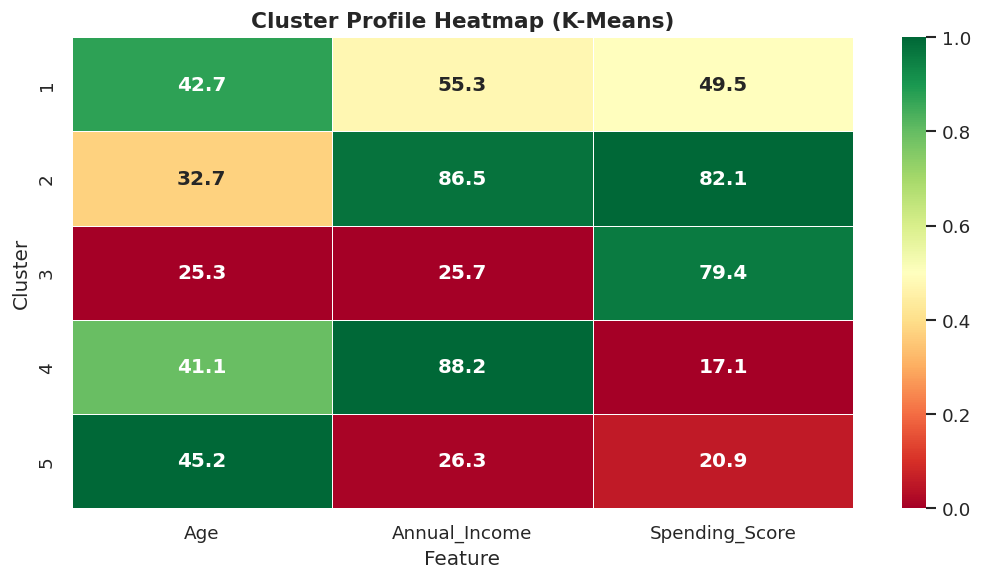

In [69]:
# ── 7.2 Cluster Profile Heatmap ───────────────────────────────────────────
plt.figure(figsize=(9, 5))
profile_scaled = profile[['Age', 'Annual_Income', 'Spending_Score']].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())   # normalize 0-1 for heatmap
)
sns.heatmap(profile_scaled, annot=profile[['Age', 'Annual_Income', 'Spending_Score']],
            fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Cluster Profile Heatmap (K-Means)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [70]:
# ── 7.3 Final Business Recommendations ───────────────────────────────────
print('=' * 65)
print('       BUSINESS INSIGHTS & RECOMMENDATIONS')
print('=' * 65)
print()
print('5 Customer Segments Identified:')
print()
print('  🔴 Segment 1 — "Careful Spenders"')
print('     Low income, low spending')
print('     → Offer budget deals, discounts, loyalty rewards')
print()
print('  🔵 Segment 2 — "Young Impulsives"')
print('     Low income, HIGH spending (likely younger customers)')
print('     → Target with trendy products, BNPL options, social media ads')
print()
print('  🟢 Segment 3 — "Average Customers"')
print('     Medium income, medium spending')
print('     → Largest segment — target with seasonal promotions')
print()
print('  🟡 Segment 4 — "Wealthy Conservatives"')
print('     High income, LOW spending')
print('     → Hard to convert — try premium exclusivity, VIP programs')
print()
print('  🟣 Segment 5 — "Premium Targets" ⭐')
print('     HIGH income, HIGH spending')
print('     → Most valuable segment — focus retention, personalized offers')
print()
print('=' * 65)
print('  🏆 Best Model: K-Means (k=5)')
print(f'     Silhouette Score: {silhouette_score(X_2d_scaled, labels_km):.4f}')
print('     Both K-Means and Hierarchical agree on 5 clusters')
print('     → Confirms robust, data-driven segmentation')
print('=' * 65)
print()


       BUSINESS INSIGHTS & RECOMMENDATIONS

5 Customer Segments Identified:

  🔴 Segment 1 — "Careful Spenders"
     Low income, low spending
     → Offer budget deals, discounts, loyalty rewards

  🔵 Segment 2 — "Young Impulsives"
     Low income, HIGH spending (likely younger customers)
     → Target with trendy products, BNPL options, social media ads

  🟢 Segment 3 — "Average Customers"
     Medium income, medium spending
     → Largest segment — target with seasonal promotions

  🟡 Segment 4 — "Wealthy Conservatives"
     High income, LOW spending
     → Hard to convert — try premium exclusivity, VIP programs

  🟣 Segment 5 — "Premium Targets" ⭐
     HIGH income, HIGH spending
     → Most valuable segment — focus retention, personalized offers

  🏆 Best Model: K-Means (k=5)
     Silhouette Score: 0.5547
     Both K-Means and Hierarchical agree on 5 clusters
     → Confirms robust, data-driven segmentation



In [71]:
# ── Segment labels lookup ─────────────────────────────────────────────────
# Build a reference: cluster number → business label
# We derive labels from the profile table (Income & Spending determine the name)

segment_labels = {}
for cluster_id in range(1, 6):
    inc = profile.loc[cluster_id, 'Annual_Income']
    spd = profile.loc[cluster_id, 'Spending_Score']
    if inc < 45 and spd < 45:
        label = '🔴 Careful Spenders    — Low income, low spending'
    elif inc < 45 and spd >= 55:
        label = '🔵 Young Impulsives    — Low income, high spending'
    elif 45 <= inc <= 75 and 40 <= spd <= 60:
        label = '🟢 Average Customers   — Medium income, medium spending'
    elif inc > 75 and spd < 45:
        label = '🟡 Wealthy Conservatives — High income, low spending'
    elif inc > 75 and spd >= 55:
        label = '🟣 Premium Targets ⭐  — High income, high spending'
    else:
        label = f'🟢 Average Customers   — Medium income, medium spending'
    segment_labels[cluster_id] = label

print('Segment label map:')
for k, v in segment_labels.items():
    print(f'  Cluster {k}: {v}')

Segment label map:
  Cluster 1: 🟢 Average Customers   — Medium income, medium spending
  Cluster 2: 🟣 Premium Targets ⭐  — High income, high spending
  Cluster 3: 🔵 Young Impulsives    — Low income, high spending
  Cluster 4: 🟡 Wealthy Conservatives — High income, low spending
  Cluster 5: 🔴 Careful Spenders    — Low income, low spending


In [72]:
# ── Prediction Function ───────────────────────────────────────────────────
def predict_customer_segment(annual_income, spending_score, gender='Female', age=30):
    """
    Predict the K-Means segment for a new customer.

    Parameters:
        annual_income  : float — Annual income in k$ (e.g. 60 means $60,000)
        spending_score : float — Spending score 1–100
        gender         : str   — 'Male' or 'Female' (informational only)
        age            : int   — Customer age (informational only)

    Returns:
        Cluster number and business label
    """
    # Scale the input using the same scaler fitted on training data
    new_customer = np.array([[annual_income, spending_score]])
    new_customer_scaled = scaler_2d.transform(new_customer)

    # Predict cluster
    cluster_num = km_final.predict(new_customer_scaled)[0] + 1
    label = segment_labels[cluster_num]

    # Distance to each centroid (confidence check)
    distances = np.linalg.norm(
        km_final.cluster_centers_ - new_customer_scaled, axis=1
    )
    closest_dist = distances[cluster_num - 1]

    print('=' * 55)
    print('         NEW CUSTOMER SEGMENT PREDICTION')
    print('=' * 55)
    print(f'  Gender         : {gender}')
    print(f'  Age            : {age}')
    print(f'  Annual Income  : ${annual_income}k')
    print(f'  Spending Score : {spending_score}/100')
    print('─' * 55)
    print(f'  Predicted Cluster : {cluster_num}')
    print(f'  Segment           : {label}')
    print(f'  Distance to center: {closest_dist:.3f} (lower = more central)')
    print('=' * 55)

    return cluster_num, label

print('✅ Prediction function ready.')

✅ Prediction function ready.


In [73]:
# ── Test with Example Customers ───────────────────────────────────────────

# Example 1 — High earner, high spender
predict_customer_segment(annual_income=95, spending_score=82, gender='Female', age=28)
print()

# Example 2 — Low income, low spending
predict_customer_segment(annual_income=20, spending_score=18, gender='Male', age=55)
print()

# Example 3 — Middle of the road
predict_customer_segment(annual_income=55, spending_score=50, gender='Female', age=35)

         NEW CUSTOMER SEGMENT PREDICTION
  Gender         : Female
  Age            : 28
  Annual Income  : $95k
  Spending Score : 82/100
───────────────────────────────────────────────────────
  Predicted Cluster : 2
  Segment           : 🟣 Premium Targets ⭐  — High income, high spending
  Distance to center: 0.323 (lower = more central)

         NEW CUSTOMER SEGMENT PREDICTION
  Gender         : Male
  Age            : 55
  Annual Income  : $20k
  Spending Score : 18/100
───────────────────────────────────────────────────────
  Predicted Cluster : 5
  Segment           : 🔴 Careful Spenders    — Low income, low spending
  Distance to center: 0.266 (lower = more central)

         NEW CUSTOMER SEGMENT PREDICTION
  Gender         : Female
  Age            : 35
  Annual Income  : $55k
  Spending Score : 50/100
───────────────────────────────────────────────────────
  Predicted Cluster : 1
  Segment           : 🟢 Average Customers   — Medium income, medium spending
  Distance to center:

(np.int32(1), '🟢 Average Customers   — Medium income, medium spending')

In [74]:
# ── Interactive: Predict YOUR OWN Customer ────────────────────────────────
# 🔧 Change these values to predict any customer!

MY_CUSTOMER = {
    'annual_income'  : 70,       # in k$ — e.g. 70 means $70,000/year
    'spending_score' : 65,       # 1 to 100
    'gender'         : 'Male',   # 'Male' or 'Female'
    'age'            : 32        # in years
}

predict_customer_segment(**MY_CUSTOMER)

         NEW CUSTOMER SEGMENT PREDICTION
  Gender         : Male
  Age            : 32
  Annual Income  : $70k
  Spending Score : 65/100
───────────────────────────────────────────────────────
  Predicted Cluster : 1
  Segment           : 🟢 Average Customers   — Medium income, medium spending
  Distance to center: 0.822 (lower = more central)


(np.int32(1), '🟢 Average Customers   — Medium income, medium spending')

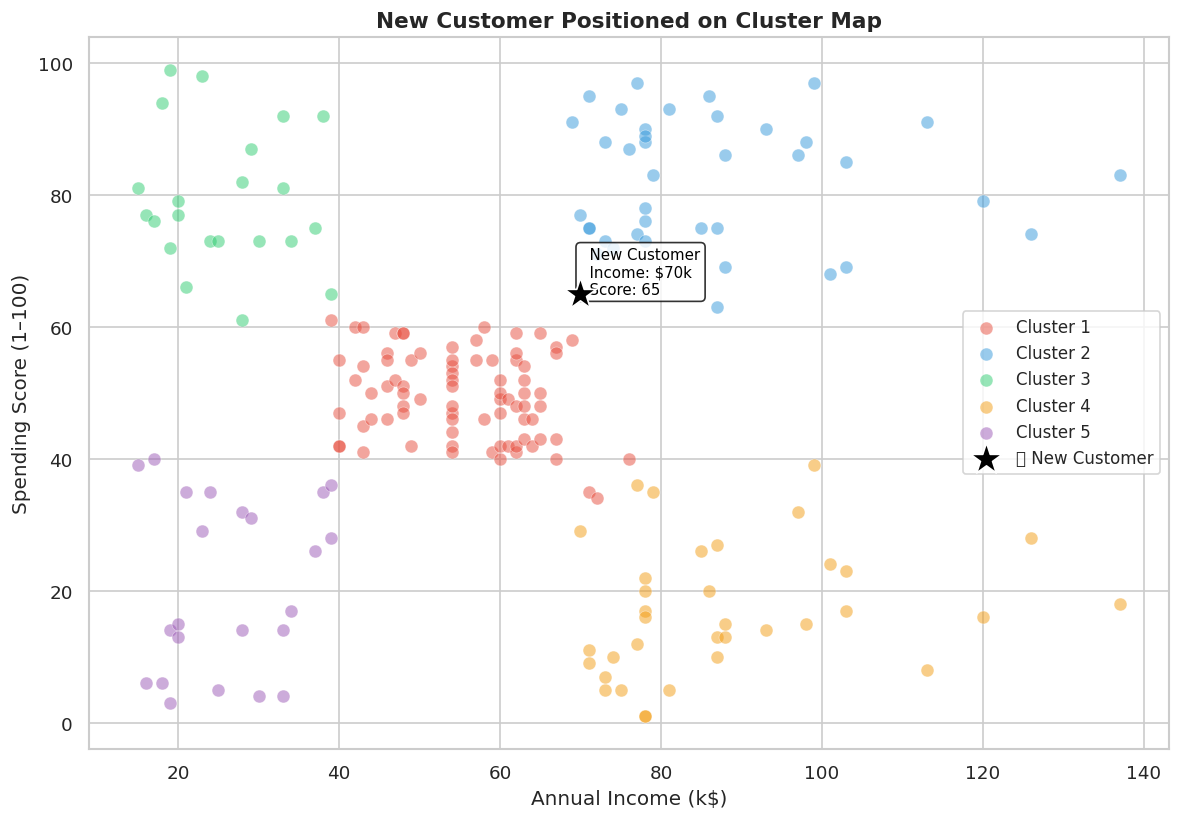

In [75]:
# ── Visualize New Customer on Cluster Map ─────────────────────────────────
def plot_new_customer(annual_income, spending_score):
    """Plot a new customer on the existing cluster map."""
    plt.figure(figsize=(10, 7))
    colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

    # Plot existing clusters
    for cluster_id, color in zip(range(1, 6), colors_list):
        subset = df[df['KMeans_Cluster'] == cluster_id]
        plt.scatter(subset['Annual_Income'], subset['Spending_Score'],
                    c=color, label=f'Cluster {cluster_id}',
                    alpha=0.5, edgecolors='white', linewidth=0.4, s=60)

    # Plot new customer as a large star
    plt.scatter(annual_income, spending_score,
                c='black', marker='*', s=400, zorder=10,
                label='🆕 New Customer', edgecolors='white', linewidth=1)

    # Annotate
    plt.annotate(
        f'  New Customer\n  Income: ${annual_income}k\n  Score: {spending_score}',
        xy=(annual_income, spending_score),
        fontsize=9, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8)
    )

    plt.xlabel('Annual Income (k$)', fontsize=12)
    plt.ylabel('Spending Score (1–100)', fontsize=12)
    plt.title('New Customer Positioned on Cluster Map', fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Plot the custom customer defined above
plot_new_customer(
    MY_CUSTOMER['annual_income'],
    MY_CUSTOMER['spending_score']
)